In [12]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [13]:
feature_df = pd.read_csv('feature_data.csv')
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
wthr_features = ['FHVEC', 'TG', 'TN', 'TX', 'T10N', 'SQ', 'RH', 'RHX', 'VVX']    
X_topo = np.array(feature_df[topo_features])
X_wthr = np.array(feature_df[wthr_features])
X_comp = np.array(feature_df.drop(columns=['source', 'destination', 'Date', 'Disrupted']))
y = np.array(feature_df['Disrupted'])

In [27]:
feature_df

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,...,SQ,TG,TN,TX,RHX,VVX,T10N,FHVEC,Date,Disrupted
0,'s-Hertogenbosch,Arnhem Centraal,14,83,31.714286,14,65,33.714286,3,0.230769,...,7.0,70.0,42.0,87.0,4.0,74.0,28.0,40.0,2019-01-01,False
1,'s-Hertogenbosch,Den Haag Centraal,14,83,31.714286,29,253,52.793103,3,0.130435,...,7.0,70.0,42.0,87.0,4.0,74.0,28.0,40.0,2019-01-01,False
2,'s-Hertogenbosch,Deurne,14,83,31.714286,3,17,18.000000,1,0.111111,...,7.0,70.0,42.0,87.0,4.0,74.0,28.0,40.0,2019-01-01,False
3,'s-Hertogenbosch,Dordrecht,14,83,31.714286,18,116,36.555556,4,0.307692,...,7.0,70.0,42.0,87.0,4.0,74.0,28.0,40.0,2019-01-01,False
4,'s-Hertogenbosch,Eindhoven Centraal,14,83,31.714286,21,116,40.142857,2,0.111111,...,7.0,70.0,42.0,87.0,4.0,74.0,28.0,40.0,2019-01-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612785,Zwolle,Nijmegen,23,104,53.608696,19,64,56.000000,7,0.411765,...,0.0,52.0,29.0,79.0,-1.0,80.0,29.0,82.0,2024-12-31,False
612786,Zwolle,Roosendaal,23,104,53.608696,18,83,53.277778,4,0.222222,...,0.0,52.0,29.0,79.0,-1.0,80.0,29.0,82.0,2024-12-31,False
612787,Zwolle,Schiphol Airport,23,104,53.608696,17,34,55.764706,6,0.375000,...,0.0,52.0,29.0,79.0,-1.0,80.0,29.0,82.0,2024-12-31,False
612788,Zwolle,Utrecht Centraal,23,104,53.608696,40,226,15.375000,5,0.151515,...,0.0,52.0,29.0,79.0,-1.0,80.0,29.0,82.0,2024-12-31,False


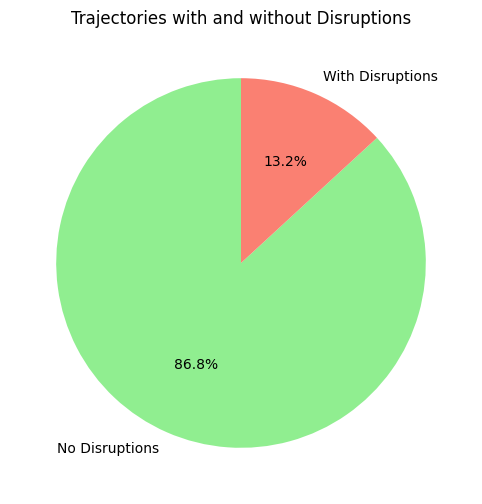

In [14]:
disrupted = (feature_df["Disrupted"] == True).sum()
non_disrupted =  (feature_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [15]:
# One-hot encode source and destination
source_encoded = pd.get_dummies(feature_df['source'], prefix='source')
destination_encoded = pd.get_dummies(feature_df['destination'], prefix='dest')

# Concatenate encoded columns with feature_df
feature_df_encoded = pd.concat([feature_df, source_encoded, destination_encoded], axis=1)

# Optionally drop original source and destination columns
feature_df_encoded = feature_df_encoded.drop(columns=['source', 'destination'])
feature_df_encoded

,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,preferential_attachment,adamic_adar_index,...,dest_Zetten-Andelst,dest_Zevenaar,dest_Zevenbergen,dest_Zoetermeer,dest_Zoetermeer Oost,dest_Zuidbroek,dest_Zuidhorn,dest_Zutphen,dest_Zwijndrecht,dest_Zwolle
0,14,83,31.714286,14,65,33.714286,3,0.230769,196,1.370312,...,False,False,False,False,False,False,False,False,False,False
1,14,83,31.714286,29,253,52.793103,3,0.130435,406,1.181065,...,False,False,False,False,False,False,False,False,False,False
2,14,83,31.714286,3,17,18.000000,1,0.111111,42,0.402430,...,False,False,False,False,False,False,False,False,False,False
3,14,83,31.714286,18,116,36.555556,4,0.307692,252,1.742067,...,False,False,False,False,False,False,False,False,False,False
4,14,83,31.714286,21,116,40.142857,2,0.111111,294,1.788671,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612785,23,104,53.608696,19,64,56.000000,7,0.411765,437,2.865774,...,False,False,False,False,False,False,False,False,False,False
612786,23,104,53.608696,18,83,53.277778,4,0.222222,414,1.773758,...,False,False,False,False,False,False,False,False,False,False
612787,23,104,53.608696,17,34,55.764706,6,0.375000,391,2.690635,...,False,False,False,False,False,False,False,False,False,False
612788,23,104,53.608696,40,226,15.375000,5,0.151515,920,2.086584,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# Define feature columns
feature_columns = [col for col in feature_df_encoded.columns 
                   if col.startswith('source_') or col.startswith('dest_') or 
                   col in topo_features]

# Ensure numeric features
feature_df_encoded[feature_columns] = feature_df_encoded[feature_columns].apply(pd.to_numeric, errors='coerce')

# Define features (X) and target (y)
X_enc = feature_df_encoded[feature_columns]
y_enc = feature_df_encoded['Disrupted'].astype(int)  # Convert True/False to 1/0

In [5]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

In [25]:
from xgboost import plot_importance
def optimise(model, scoring, param_grid, X, y):
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit='f1',
        cv=5,
        verbose=1,
        n_jobs=1
    )
    # random_search = RandomizedSearchCV(
    #     estimator=model,
    #     param_distributions=param_grid,
    #     n_iter=50,
    #     scoring=scoring,
    #     refit='f1',
    #     cv=5,
    #     verbose=1,
    #     n_jobs=-1,
    #     random_state=42
    # )
    grid_search.fit(X_train, y_train)
    # grid_search = random_search
    # Results
    print("Best Parameters:", grid_search.best_params_)
    print("Best F1 Score:", grid_search.best_score_)

    # Evaluate best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")

    # Feature importance
    plot_importance(best_model, max_num_features=20)
    plt.show()
    
    return best_model

In [26]:
xgb_model = optimise(xgb, scoring, param_grid, X_enc, y_enc)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML

KeyboardInterrupt: 

In [19]:
best_parameters= {'subsample': 0.8, 'scale_pos_weight': 66.6443316039298, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.6}

In [42]:
def compare_models(X, y, resample=True):
    scaler = StandardScaler()
    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

    # apply SMOTE to training set, create validation set
    if resample:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        X_train, X_val, y_train, y_val = train_test_split(
        X_balanced, y_balanced, test_size=0.3, random_state=42
        )
    # Scale the features
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    if resample:
        X_val_scaled = scaler.transform(X_val)

    logres = LogisticRegression(random_state=42, class_weight='balanced')
    rf = RandomForestClassifier(random_state=42, class_weight='balanced')
    xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, class_weight='balanced')
    gbdt = GradientBoostingClassifier(random_state=42, class_weight='balanced')
    
    classifiers = [logres, rf, xgb, gbdt]
    for classifier in classifiers:
        # Fit the classifier
        classifier.fit(X_train_scaled, y_train)
        if resample:
            y_pred = classifier.predict(X_val_scaled)
            # Evaluate on the validation set
            print(f"Validation set evaluation for {classifier.__class__.__name__}:")
            print(f"Classifier: {classifier.__class__.__name__}")
            print(classification_report(y_val, y_pred))
            print(confusion_matrix(y_val, y_pred))
            print("\n")
        # Evaluate on the test set
        y_test_pred = classifier.predict(X_test_scaled)
        print(f"Test set evaluation for {classifier.__class__.__name__}:")
        print(classification_report(y_test, y_test_pred))
        cm_test = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disruption', 'Disruption'], yticklabels=['No Disruption', 'Disruption'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix (Test)')
        plt.show()

In [43]:
compare_models(X_topo, y, False)

TypeError: GradientBoostingClassifier.__init__() got an unexpected keyword argument 'class_weight'

Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.66      0.74      0.70    111653
        True       0.70      0.61      0.66    111876

    accuracy                           0.68    223529
   macro avg       0.68      0.68      0.68    223529
weighted avg       0.68      0.68      0.68    223529

[[82821 28832]
 [43086 68790]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       0.92      0.74      0.82    159617
        True       0.26      0.60      0.36     24220

    accuracy                           0.72    183837
   macro avg       0.59      0.67      0.59    183837
weighted avg       0.84      0.72      0.76    183837



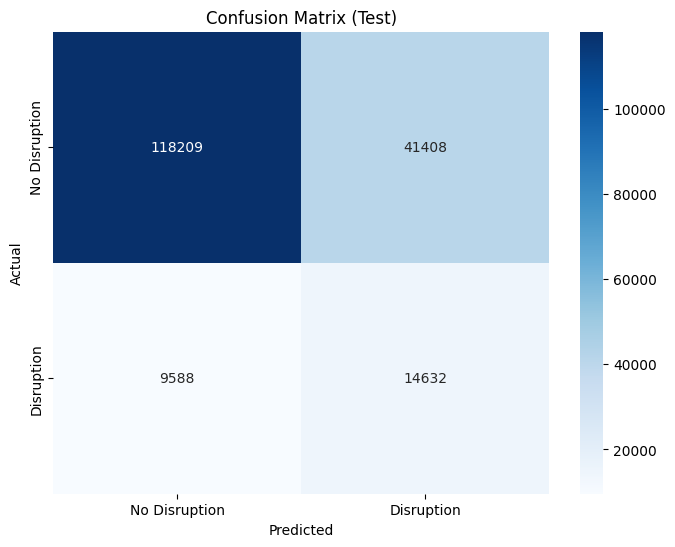

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       0.91      0.91      0.91    111653
        True       0.91      0.91      0.91    111876

    accuracy                           0.91    223529
   macro avg       0.91      0.91      0.91    223529
weighted avg       0.91      0.91      0.91    223529

[[101080  10573]
 [ 10151 101725]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91    159617
        True       0.42      0.44      0.43     24220

    accuracy                           0.85    183837
   macro avg       0.67      0.68      0.67    183837
weighted avg       0.85      0.85      0.85    183837



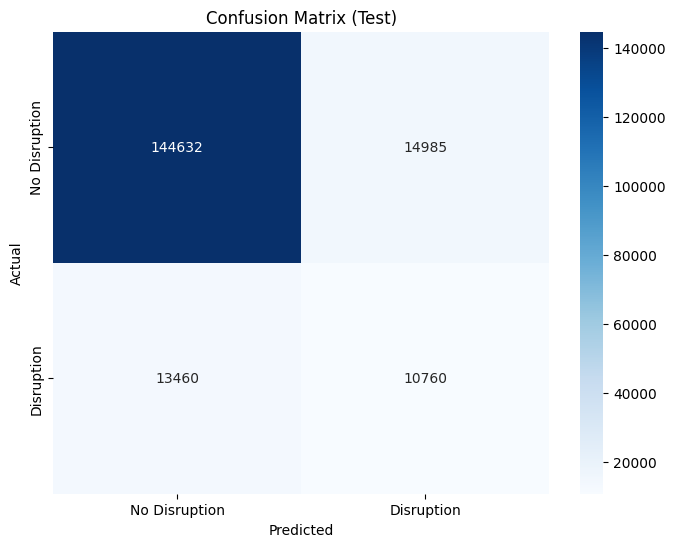

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.83      0.86      0.85    111653
        True       0.85      0.83      0.84    111876

    accuracy                           0.84    223529
   macro avg       0.84      0.84      0.84    223529
weighted avg       0.84      0.84      0.84    223529

[[95828 15825]
 [18944 92932]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.92      0.86      0.89    159617
        True       0.36      0.53      0.43     24220

    accuracy                           0.82    183837
   macro avg       0.64      0.69      0.66    183837
weighted avg       0.85      0.82      0.83    183837



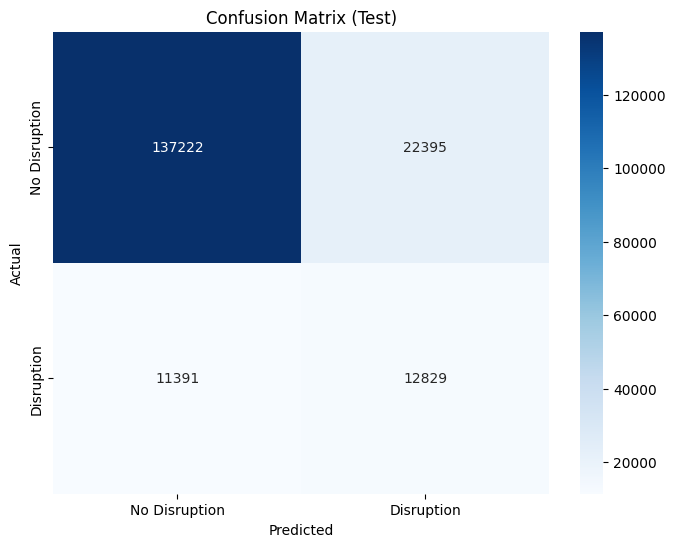

Validation set evaluation for GradientBoostingClassifier:
Classifier: GradientBoostingClassifier
              precision    recall  f1-score   support

       False       0.79      0.75      0.77    111653
        True       0.76      0.80      0.78    111876

    accuracy                           0.77    223529
   macro avg       0.77      0.77      0.77    223529
weighted avg       0.77      0.77      0.77    223529

[[83363 28290]
 [22241 89635]]


Test set evaluation for GradientBoostingClassifier:
              precision    recall  f1-score   support

       False       0.93      0.75      0.83    159617
        True       0.28      0.65      0.39     24220

    accuracy                           0.73    183837
   macro avg       0.61      0.70      0.61    183837
weighted avg       0.85      0.73      0.77    183837



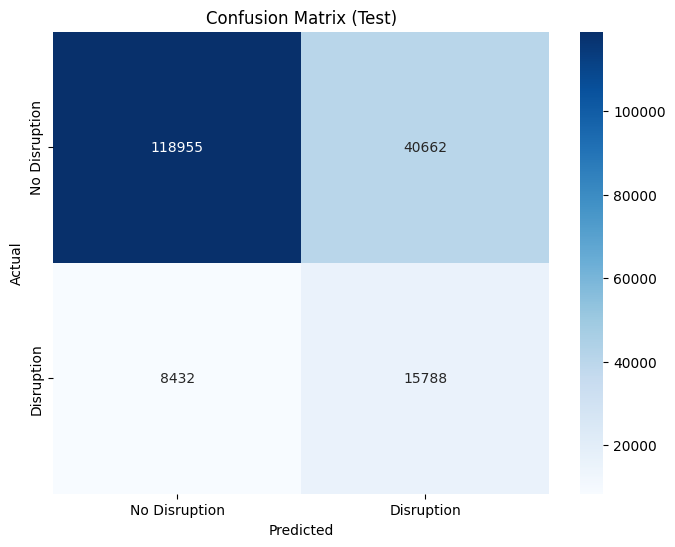

In [41]:
compare_models(X_topo, y, True)

Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.53      0.54      0.54    126838
        True       0.53      0.52      0.53    126763

    accuracy                           0.53    253601
   macro avg       0.53      0.53      0.53    253601
weighted avg       0.53      0.53      0.53    253601

[[68974 57864]
 [60621 66142]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       0.99      0.55      0.70    181064
        True       0.02      0.49      0.03      2773

    accuracy                           0.55    183837
   macro avg       0.50      0.52      0.37    183837
weighted avg       0.97      0.55      0.69    183837



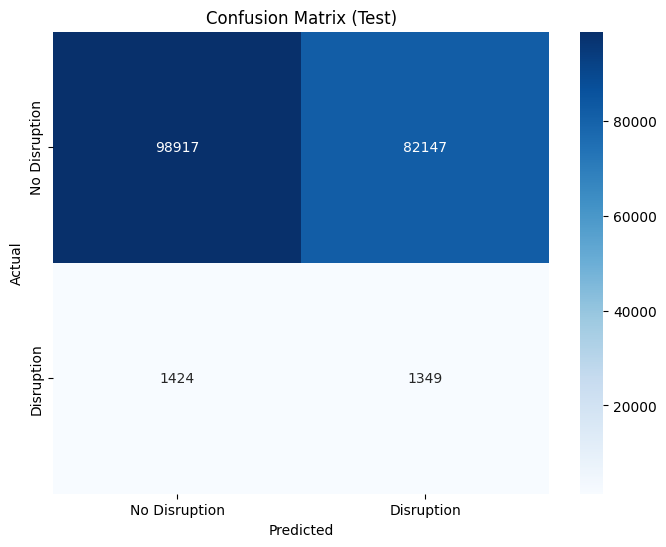

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       0.94      0.96      0.95    126838
        True       0.96      0.94      0.95    126763

    accuracy                           0.95    253601
   macro avg       0.95      0.95      0.95    253601
weighted avg       0.95      0.95      0.95    253601

[[121437   5401]
 [  7669 119094]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.99      0.96      0.97    181064
        True       0.02      0.05      0.03      2773

    accuracy                           0.94    183837
   macro avg       0.50      0.50      0.50    183837
weighted avg       0.97      0.94      0.96    183837



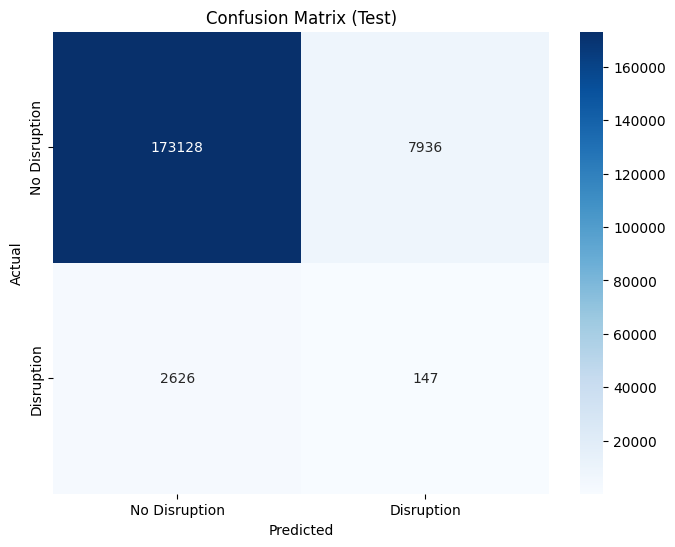

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.84      0.98      0.90    126838
        True       0.97      0.82      0.89    126763

    accuracy                           0.90    253601
   macro avg       0.91      0.90      0.90    253601
weighted avg       0.91      0.90      0.90    253601

[[123718   3120]
 [ 22936 103827]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    181064
        True       0.02      0.03      0.02      2773

    accuracy                           0.96    183837
   macro avg       0.50      0.50      0.50    183837
weighted avg       0.97      0.96      0.97    183837



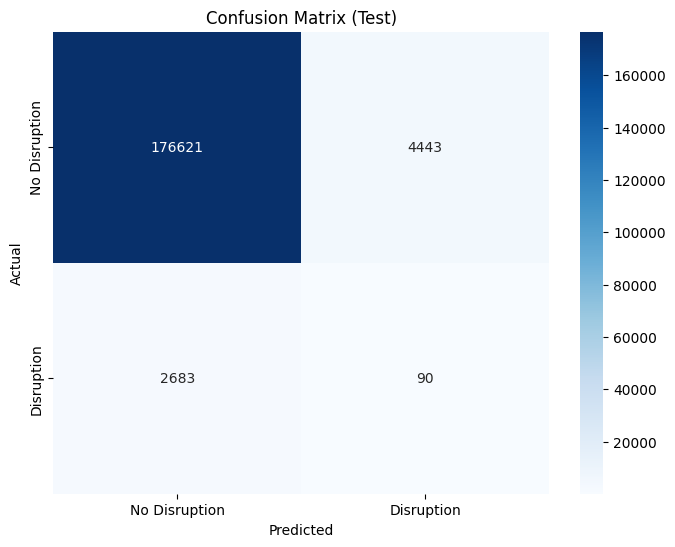

In [31]:
compare_models(X_wthr, y)

Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

       False       0.79      0.72      0.75    126838
        True       0.74      0.80      0.77    126763

    accuracy                           0.76    253601
   macro avg       0.76      0.76      0.76    253601
weighted avg       0.76      0.76      0.76    253601

[[ 90991  35847]
 [ 24910 101853]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

       False       1.00      0.72      0.84    181064
        True       0.04      0.80      0.08      2773

    accuracy                           0.72    183837
   macro avg       0.52      0.76      0.46    183837
weighted avg       0.98      0.72      0.82    183837



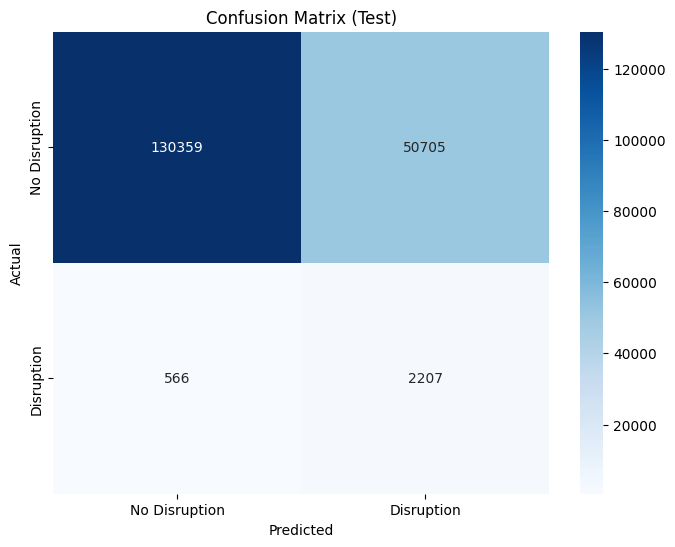

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

       False       1.00      0.99      0.99    126838
        True       0.99      1.00      0.99    126763

    accuracy                           0.99    253601
   macro avg       0.99      0.99      0.99    253601
weighted avg       0.99      0.99      0.99    253601

[[125103   1735]
 [   581 126182]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    181064
        True       0.26      0.31      0.28      2773

    accuracy                           0.98    183837
   macro avg       0.62      0.65      0.63    183837
weighted avg       0.98      0.98      0.98    183837



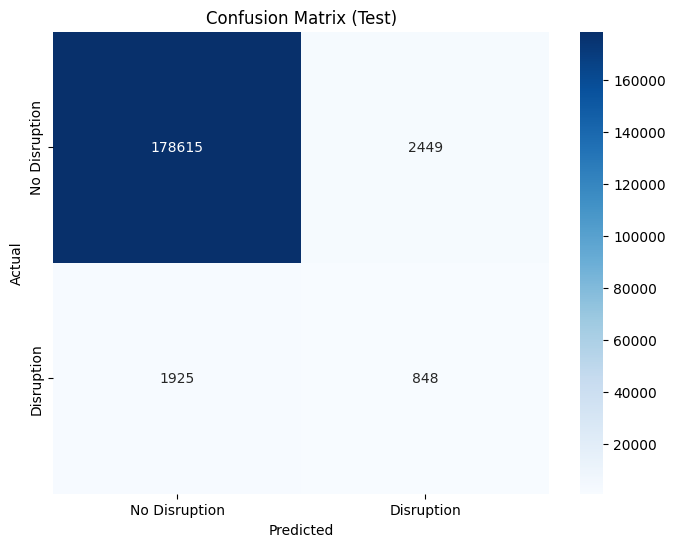

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    126838
        True       0.98      0.99      0.98    126763

    accuracy                           0.98    253601
   macro avg       0.98      0.98      0.98    253601
weighted avg       0.98      0.98      0.98    253601

[[124300   2538]
 [  1759 125004]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

       False       0.99      0.98      0.99    181064
        True       0.23      0.37      0.28      2773

    accuracy                           0.97    183837
   macro avg       0.61      0.68      0.63    183837
weighted avg       0.98      0.97      0.98    183837



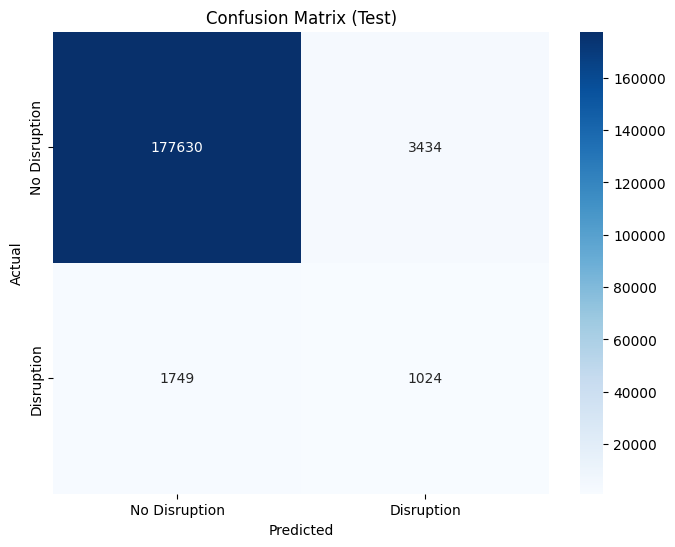

In [34]:
compare_models(X_comp, y)

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation set evaluation for LogisticRegression:
Classifier: LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    126838
           1       0.92      1.00      0.95    126763

    accuracy                           0.95    253601
   macro avg       0.96      0.95      0.95    253601
weighted avg       0.96      0.95      0.95    253601

[[115185  11653]
 [   307 126456]]


Test set evaluation for LogisticRegression:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    181064
           1       0.14      0.99      0.25      2773

    accuracy                           0.91    183837
   macro avg       0.57      0.95      0.60    183837
weighted avg       0.99      0.91      0.94    183837



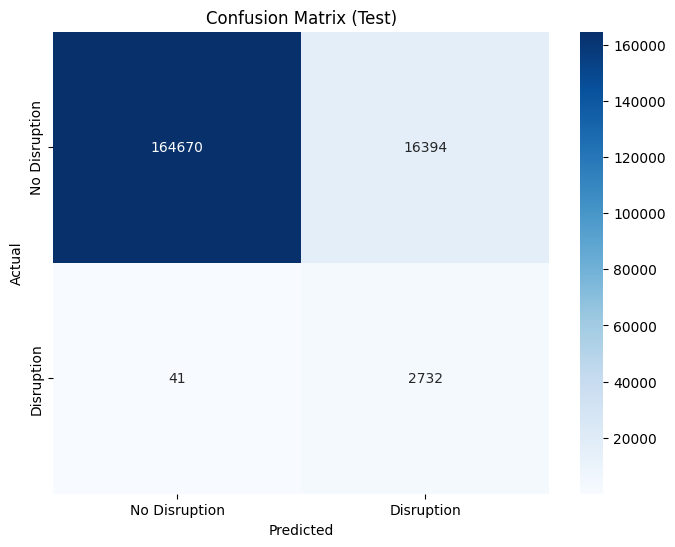

Validation set evaluation for RandomForestClassifier:
Classifier: RandomForestClassifier
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    126838
           1       0.97      1.00      0.98    126763

    accuracy                           0.98    253601
   macro avg       0.98      0.98      0.98    253601
weighted avg       0.98      0.98      0.98    253601

[[123110   3728]
 [   459 126304]]


Test set evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    181064
           1       0.20      0.49      0.29      2773

    accuracy                           0.96    183837
   macro avg       0.60      0.73      0.64    183837
weighted avg       0.98      0.96      0.97    183837



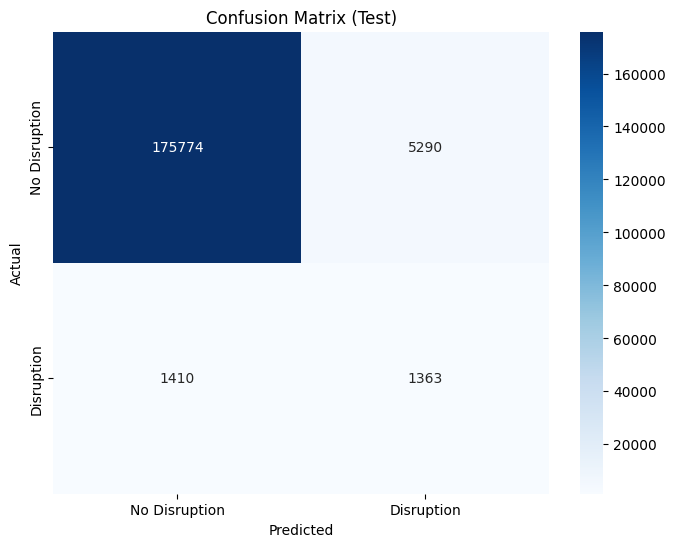

Validation set evaluation for XGBClassifier:
Classifier: XGBClassifier
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    126838
           1       0.93      1.00      0.96    126763

    accuracy                           0.96    253601
   macro avg       0.96      0.96      0.96    253601
weighted avg       0.96      0.96      0.96    253601

[[117174   9664]
 [   252 126511]]


Test set evaluation for XGBClassifier:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    181064
           1       0.16      0.93      0.27      2773

    accuracy                           0.93    183837
   macro avg       0.58      0.93      0.62    183837
weighted avg       0.99      0.93      0.95    183837



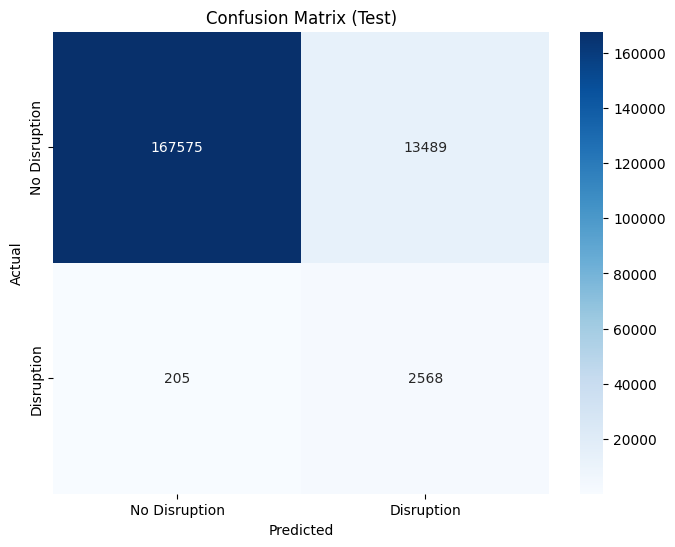

In [8]:
compare_models(X_enc, y_enc)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

features = feature_df.drop(columns=['Disrupted', 'Date']).columns.tolist()

# Drop the 'Date' column from X_comp
#X_comp = np.delete(X_comp, feature_df.columns.get_loc('Date'), axis=1)
# Reshape X_comp for LSTM
X_comp_reshaped = X_comp.reshape((X_comp.shape[0], 1, X_comp.shape[1]))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_comp_reshaped, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.reshape(-1, X_train.shape[2]), y_train)
X_train = X_train_resampled.reshape(-1, 1, X_train.shape[2])
y_train = y_train_resampled

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Convert labels to categorical (if necessary)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Train the model
early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_categorical, 
    epochs=50,  # Increase epochs
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
y_pred = model.predict(X_test_scaled)
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Calculate feature importance using the model's weights
feature_importance = np.mean(np.abs(model.layers[0].get_weights()[0]), axis=1)

# Map feature importance to feature names
feature_importance_dict = dict(zip(features, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Print sorted feature importance
print("Feature Importance:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance}")

# Print classification report and confusion matrix
print(classification_report(y_test_classes, y_pred_classes))
print(confusion_matrix(y_test_classes, y_pred_classes))

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - AUC: 0.9523 - Precision: 0.8850 - Recall: 0.8850 - accuracy: 0.8850 - loss: 0.2669 - val_AUC: 0.9834 - val_Precision: 0.9493 - val_Recall: 0.9493 - val_accuracy: 0.9493 - val_loss: 0.1890
Epoch 2/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - AUC: 0.9821 - Precision: 0.9365 - Recall: 0.9365 - accuracy: 0.9365 - loss: 0.1674 - val_AUC: 0.9944 - val_Precision: 0.9744 - val_Recall: 0.9744 - val_accuracy: 0.9744 - val_loss: 0.1303
Epoch 3/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - AUC: 0.9860 - Precision: 0.9457 - Recall: 0.9457 - accuracy: 0.9457 - loss: 0.1471 - val_AUC: 0.9957 - val_Precision: 0.9785 - val_Recall: 0.9785 - val_accuracy: 0.9785 - val_loss: 0.1291
Epoch 4/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - AUC: 0.9881 - Precision: 0.9518 - Recall: 0.9518 - accuracy: 0.9518 - loss: 0.1339 - val_AUC: 0.9971 - val_Precision: 0.9868 - val_Recall: 0.9868 - val_accuracy: 0.9868 - val_loss: 0.1053
Epoch 5/50
2

In [25]:
features = feature_df.drop(columns=['Disrupted', 'Date']).columns.tolist()

# Drop the 'Date' column from X_comp
#X_comp = np.delete(X_comp, feature_df.columns.get_loc('Date'), axis=1)
# Reshape X_comp for LSTM
X_topo_reshaped = X_topo.reshape((X_topo.shape[0], 1, X_topo.shape[1]))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_topo_reshaped, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.reshape(-1, X_train.shape[2]), y_train)
X_train = X_train_resampled.reshape(-1, 1, X_train.shape[2])
y_train = y_train_resampled

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Convert labels to categorical (if necessary)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Train the model
early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_categorical, 
    epochs=50,  # Increase epochs
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
y_pred = model.predict(X_test_scaled)
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Calculate feature importance using the model's weights
feature_importance = np.mean(np.abs(model.layers[0].get_weights()[0]), axis=1)

# Map feature importance to feature names
feature_importance_dict = dict(zip(features, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Print sorted feature importance
print("Feature Importance:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance}")

# Print classification report and confusion matrix
print(classification_report(y_test_classes, y_pred_classes))
print(confusion_matrix(y_test_classes, y_pred_classes))

Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21131/21131 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - AUC: 0.9541 - Precision: 0.8884 - Recall: 0.8884 - accuracy: 0.8884 - loss: 0.2624 - val_AUC: 0.9815 - val_Precision: 0.9610 - val_Recall: 0.9610 - val_accuracy: 0.9610 - val_loss: 0.2077
Epoch 2/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - AUC: 0.9797 - Precision: 0.9339 - Recall: 0.9339 - accuracy: 0.9339 - loss: 0.1770 - val_AUC: 0.9900 - val_Precision: 0.9710 - val_Recall: 0.9710 - val_accuracy: 0.9710 - val_loss: 0.1596
Epoch 3/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - AUC: 0.9825 - Precision: 0.9401 - Recall: 0.9401 - accuracy: 0.9401 - loss: 0.1631 - val_AUC: 0.9915 - val_Precision: 0.9751 - val_Recall: 0.9751 - val_accuracy: 0.9751 - val_loss: 0.1587
Epoch 4/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 74s 4ms/step - AUC: 0.9839 - Precision: 0.9430 - Recall: 0.9430 - accuracy: 0.9430 - loss: 0.1561 - val_AUC: 0.9972 - val_Precision: 0.9897 - val_Recall: 0.9897 - val_accuracy: 0.9897 - val_loss: 0.1258
Epoch 5/50
21131/21131 

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

features = feature_df_encoded.drop(columns=['Disrupted', 'Date']).columns.tolist()

# Drop the 'Date' column from X_comp
#X_comp = np.delete(X_comp, feature_df.columns.get_loc('Date'), axis=1)
# Reshape X_comp for LSTM
X_enc = np.array(X_enc)
X_enc_reshaped = X_enc.reshape((X_enc.shape[0], 1, X_enc.shape[1]))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_enc_reshaped, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.reshape(-1, X_train.shape[2]), y_train)
X_train = X_train_resampled.reshape(-1, 1, X_train.shape[2])
y_train = y_train_resampled

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Convert labels to categorical (if necessary)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Train the model
early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_categorical, 
    epochs=50,  # Increase epochs
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
y_pred = model.predict(X_test_scaled)
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Calculate feature importance using the model's weights
feature_importance = np.mean(np.abs(model.layers[0].get_weights()[0]), axis=1)

# Map feature importance to feature names
feature_importance_dict = dict(zip(features, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Print sorted feature importance
print("Feature Importance:")
for feature, importance in sorted_features:
    print(f"{feature}: {importance}")

# Print classification report and confusion matrix
print(classification_report(y_test_classes, y_pred_classes))
print(confusion_matrix(y_test_classes, y_pred_classes))

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 99s 4ms/step - AUC: 0.9814 - Precision: 0.9402 - Recall: 0.9402 - accuracy: 0.9402 - loss: 0.1627 - val_AUC: 0.9997 - val_Precision: 0.9957 - val_Recall: 0.9957 - val_accuracy: 0.9957 - val_loss: 0.1348
Epoch 2/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 97s 5ms/step - AUC: 0.9861 - Precision: 0.9479 - Recall: 0.9479 - accuracy: 0.9479 - loss: 0.1441 - val_AUC: 0.9996 - val_Precision: 0.9964 - val_Recall: 0.9964 - val_accuracy: 0.9964 - val_loss: 0.1319
Epoch 3/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 100s 5ms/step - AUC: 0.9865 - Precision: 0.9486 - Recall: 0.9486 - accuracy: 0.9486 - loss: 0.1420 - val_AUC: 0.9991 - val_Precision: 0.9902 - val_Recall: 0.9902 - val_accuracy: 0.9902 - val_loss: 0.1298
Epoch 4/50
21131/21131 ━━━━━━━━━━━━━━━━━━━━ 102s 5ms/step - AUC: 0.9868 - Precision: 0.9491 - Recall: 0.9491 - accuracy: 0.9491 - loss: 0.1405 - val_AUC: 0.9994 - val_Precision: 0.9964 - val_Recall: 0.9964 - val_accuracy: 0.9964 - val_loss: 0.1172
Epoch 5/50

In [ ]:
import shap
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define features
features = feature_df.drop(columns=['Disrupted', 'Date']).columns.tolist()
features = features[:-1]
print("Features:", features)

# Ensure numpy arrays
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)
print("X_train_scaled shape:", X_train_scaled.shape)  # e.g., (n_train, 1, n_features)
print("X_test_scaled shape:", X_test_scaled.shape)    # e.g., (n_test, 1, n_features)

# Use GradientExplainer
explainer = shap.GradientExplainer(model, X_train_scaled[0:100])

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test_scaled[0:10])

# Check shapes
print("SHAP values shape:", [sv.shape for sv in shap_values])  # e.g., [(n_test, 1, n_features), (n_test, 1, n_features)]

# Manually compute the expected value (average prediction over background)
background_predictions = model.predict(X_train_scaled[0:100])
expected_value = np.mean(background_predictions, axis=0)
print("Expected value:", expected_value)  # e.g., [0.9, 0.1] for class 0 and 1

# Since LSTM has a timestep dimension (e.g., 1), squeeze it for plotting
# For class 1 (positive class)
shap_values_class1 = np.squeeze(shap_values[1])  # Shape: (n_test, n_features)
X_test_scaled_squeezed = np.squeeze(X_test_scaled[0:10])  # Shape: (n_test, n_features)


# --- 1. Force Plot (Individual Prediction) ---
# Initialize JS visualization (for Jupyter)
shap.initjs()
print(len(features))
print(len(shap_values_class1))
# Force plot for the first test instance, class 1
shap.force_plot(
    expected_value[1],          # Base value for class 1
    shap_values_class1,      # SHAP values for first instance, class 1
    X_test_scaled_squeezed,  # Feature values for first instance
    feature_names=features
)

# --- 2. Summary Plot (Global Feature Importance) ---
# Summary plot for all test instances, class 1
shap.summary_plot(
    shap_values_class1,         # SHAP values for class 1
    X_test_scaled_squeezed,     # Feature values
    feature_names=features,
    plot_type="bar"             # Optional: "bar" for bar plot, default is scatter
)

# --- 3. Dependence Plot (Feature Effect) ---
# Dependence plot for a specific feature (e.g., feature index 0)
feature_idx = 0  # Change this to the feature you want to analyze
shap.dependence_plot(
    feature_idx,                # Index of the feature
    shap_values_class1,         # SHAP values for class 1
    X_test_scaled_squeezed,     # Feature values
    feature_names=features
)

# Optional: Save plots if not in Jupyter
# shap.save_html("force_plot.html", shap.force_plot(expected_value[1], shap_values_class1[0], X_test_scaled_squeezed[0], feature_names=features))
# plt.savefig("summary_plot.png")
# plt.savefig("dependence_plot.png")

Features: ['source_degree', 'source_weighted_degree', 'source_avg_distance', 'target_degree', 'target_weighted_degree', 'target_avg_distance', 'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 'adamic_adar_index', 'resource_allocation_index', 'weight', 'distance', 'RH', 'SQ', 'TG', 'TN', 'TX', 'RHX', 'VVX', 'T10N', 'FHVEC']
X_train_scaled shape: (845224, 1, 22)
X_test_scaled shape: (183837, 1, 22)


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 1, 22))']
  warnings.warn(msg)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 1, 22))']
  warnings.warn(msg)


SHAP values shape: [(1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2), (1, 22, 2)]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Expected value: [0.95746523 0.0425348 ]


22
22


IndexError: index 10 is out of bounds for axis 0 with size 10

In [29]:
from sklearn.utils.class_weight import compute_class_weight
X_train, X_test, y_train, y_test = train_test_split(X_comp_reshaped, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Convert labels to categorical (if necessary)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train the model
early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_categorical, 
    epochs=50,  # Increase epochs
    batch_size=32, 
    validation_split=0.2, 
    class_weight=class_weight_dict,  # Adjust class weights
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
y_pred = model.predict(X_test_scaled)
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Print classification report and confusion matrix
print(classification_report(y_test_classes, y_pred_classes))
print(confusion_matrix(y_test_classes, y_pred_classes))

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - AUC: 0.8216 - Precision: 0.7291 - Recall: 0.7291 - accuracy: 0.7291 - loss: 0.4985 - val_AUC: 0.8761 - val_Precision: 0.7597 - val_Recall: 0.7597 - val_accuracy: 0.7597 - val_loss: 0.4464
Epoch 2/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - AUC: 0.9093 - Precision: 0.8060 - Recall: 0.8060 - accuracy: 0.8060 - loss: 0.3471 - val_AUC: 0.8943 - val_Precision: 0.7923 - val_Recall: 0.7923 - val_accuracy: 0.7923 - val_loss: 0.4002
Epoch 3/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - AUC: 0.9315 - Precision: 0.8397 - Recall: 0.8397 - accuracy: 0.8397 - loss: 0.3059 - val_AUC: 0.9418 - val_Precision: 0.8571 - val_Recall: 0.8571 - val_accuracy: 0.8571 - val_loss: 0.3286
Epoch 4/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - AUC: 0.9445 - Precision: 0.8559 - Recall: 0.8559 - accuracy: 0.8559 - loss: 0.2813 - val_AUC: 0.9539 - val_Precision: 0.8647 - val_Recall: 0.8647 - val_accuracy: 0.8647 - val_loss: 0.2819
Epoch 5/50
1

In [27]:
from sklearn.utils.class_weight import compute_class_weight
X_train, X_test, y_train, y_test = train_test_split(X_topo_reshaped, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Convert labels to categorical (if necessary)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), activation='relu', return_sequences=True))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Train the model
early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
history = model.fit(
    X_train_scaled, y_train_categorical, 
    epochs=50,  # Increase epochs
    batch_size=32, 
    validation_split=0.2, 
    class_weight=class_weight_dict,  # Adjust class weights
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
y_pred = model.predict(X_test_scaled)
# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Print classification report and confusion matrix
print(classification_report(y_test_classes, y_pred_classes))
print(confusion_matrix(y_test_classes, y_pred_classes))

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - AUC: 0.8589 - Precision: 0.7602 - Recall: 0.7602 - accuracy: 0.7602 - loss: 0.4576 - val_AUC: 0.9324 - val_Precision: 0.8574 - val_Recall: 0.8574 - val_accuracy: 0.8574 - val_loss: 0.3347
Epoch 2/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - AUC: 0.9258 - Precision: 0.8479 - Recall: 0.8479 - accuracy: 0.8479 - loss: 0.3220 - val_AUC: 0.9566 - val_Precision: 0.8883 - val_Recall: 0.8883 - val_accuracy: 0.8883 - val_loss: 0.2795
Epoch 3/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - AUC: 0.9429 - Precision: 0.8621 - Recall: 0.8621 - accuracy: 0.8621 - loss: 0.2903 - val_AUC: 0.9467 - val_Precision: 0.8635 - val_Recall: 0.8635 - val_accuracy: 0.8635 - val_loss: 0.3023
Epoch 4/50
10724/10724 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - AUC: 0.9513 - Precision: 0.8709 - Recall: 0.8709 - accuracy: 0.8709 - loss: 0.2639 - val_AUC: 0.9392 - val_Precision: 0.8516 - val_Recall: 0.8516 - val_accuracy: 0.8516 - val_loss: 0.3309
Epoch 5/50
1